# path2space companion — demo notebook

A two-slide demo of the Path2Space gene-expression model:

1. **TCGA-BRCA H&E slide** (grid mode) — predicts spatial expression on a non-overlapping tile grid. Bring your own `.svs` from the [GDC portal](https://portal.gdc.cancer.gov/) (set `P2S_TCGA_SLIDE`).
2. **HEST NCBI776 Visium sample** (spots mode) — predicts spatial expression at Visium spot coordinates. Demo files are auto-fetched from Zenodo.

Trained weights (~6.7 GB) are auto-fetched from [Zenodo 10.5281/zenodo.20174301](https://doi.org/10.5281/zenodo.20174301) on first run. HEST demo data is auto-fetched from [Zenodo 10.5281/zenodo.20183759](https://doi.org/10.5281/zenodo.20183759).

| variable | description | default |
|---|---|---|
| `P2S_TCGA_SLIDE` | path to a TCGA-BRCA `.svs` slide | None (skip TCGA section if unset) |


In [1]:
import os, sys, time, subprocess
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for d in [cur, *cur.parents]:
        if (d / "setup.py").exists() and (d / "path2space").is_dir():
            return d
    raise RuntimeError(f"Could not find path2space repo root from {start}")

REPO_ROOT = _find_repo_root(Path("."))
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from path2space import Path2SpacePipeline

print('repo root :', REPO_ROOT)
print('torch.cuda.is_available():', torch.cuda.is_available())


repo root : /vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model
torch.cuda.is_available(): True


## Setup: trained weights and demo data

On first run the next cell fetches:

- **Trained weights** (~6.7 GB) from Zenodo record [`20174301`](https://doi.org/10.5281/zenodo.20174301) — via `scripts/copy_weights.sh`.
- **HEST NCBI776 demo files** (~862 MB) from Zenodo record [`20183759`](https://doi.org/10.5281/zenodo.20183759) — directly via `wget`.

Subsequent runs detect existing files and skip the download.


In [2]:
HEST_RECORD_ID = "20183759"

weights_dir = REPO_ROOT / "weights"
hest_dir = REPO_ROOT / "examples" / "hest_data"

# Weights
if not (weights_dir / "ctranspath.pth").exists() or not (weights_dir / "mlp_ensemble").exists():
    print("Weights not found — fetching from Zenodo 10.5281/zenodo.20174301 ...")
    subprocess.run(["bash", str(REPO_ROOT / "scripts" / "copy_weights.sh")], check=True, cwd=REPO_ROOT)
else:
    print(f"Weights present at {weights_dir}")

# HEST demo data
hest_slide = hest_dir / "NCBI776.tif"
hest_spots = hest_dir / "NCBI776_spots.pkl"
if not hest_slide.exists() or not hest_spots.exists():
    print(f"HEST demo data not found — fetching from Zenodo 10.5281/zenodo.{HEST_RECORD_ID} ...")
    hest_dir.mkdir(parents=True, exist_ok=True)
    for fname in ["NCBI776.tif", "NCBI776_spots.pkl", "MD5SUMS.txt"]:
        subprocess.run(
            ["wget", "-c", "-O", str(hest_dir / fname),
             f"https://zenodo.org/records/{HEST_RECORD_ID}/files/{fname}"],
            check=True,
        )
    subprocess.run(["md5sum", "-c", "MD5SUMS.txt"], check=True, cwd=hest_dir)
else:
    print(f"HEST demo data present at {hest_dir}")


Weights present at /vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/weights
HEST demo data not found — fetching from Zenodo 10.5281/zenodo.20183759 ...


Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/home/shulmaned/.wget-hsts'. HSTS will be disabled.
--2026-05-14 10:50:25--  https://zenodo.org/records/20183759/files/NCBI776.tif
Resolving dtn19-e0 (dtn19-e0)... 10.1.200.73
Connecting to dtn19-e0 (dtn19-e0)|10.1.200.73|:3128... connected.


Proxy request sent, awaiting response... 

200 OK
Length: 903400753 (862M) [image/tiff]
Saving to: ‘/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/examples/hest_data/NCBI776.tif’

     0K .......... .......... .......... ..

........ ..........  0%  185K 79m31s
    50K .......... .......... .......... .......... ..........  0%  558K 52m56s
   100K .......... .......... .......... .......... ..........  0% 8.39M 35m52s
   150K .......... .......... .......... .......... ..........  0% 1.49M 29m19s
   200K .......... .......... .......... .......... ..........  0%  926K 26m37s
   250K .......... .......... .......... .......... ..........  0% 26.2M 22m16s
   300K .......... .......... .......... .......... ..........  0%  544M 19m6s
   350K .......... .......... .......... .......... ..........  0%  504M 16m43s
   400K ......

...

Proxy request sent, awaiting response... 200 OK
Length: 429730 (420K) [application/octet-stream]
Saving to: ‘/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/examples/hest_data/NCBI776_spots.pkl’

     0K .......... .

......... .......... .......... .......... 11%  260K 1s
    50K .......... .......... .......... .......... .......... 23%  559K 1s
   100K .......... .......... .......... .......... .......... 35% 8.38M 1s
   150K .......... .......... .......... .......... ........

.. 47%  598K 0s
   200K .......... .......... .......... .......... .......... 59% 8.20M 0s
   250K .......... .......... .......... .......... .......... 71% 7.55M 0s
   300K .......... .......... .......... .......... .......... 83% 26.3M 0s
   350K .......... .......... .......... .......... .......... 95%  601M 0s
   400K .......... .........                                  100%  718K=0.4s

2026-05-14 10:51:44 (1017 KB/s) - ‘/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/examples/hest_data/NCBI776_spots.pkl’ saved [429730/429730]

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/home/shulmaned/.wget-hsts'. HSTS will be disabled.
--2026-05-14 10:51:44--  https://zenodo.org/records/20183759/files/MD5SUMS.txt
Resolving dtn19-e0 (dtn19-e0)... 10.1.200.73
Connecting to dtn19-e0 (dtn19-e0)|10.1.200.73|:3128... connected.


Proxy request sent, awaiting response... 200 OK
Length: 98 [text/plain]
Saving to: ‘/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/examples/hest_data/MD5SUMS.txt’

     0K                                                       100%  282M=0s

2026-05-14 10:51:44 (282 MB/s) - ‘/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/examples/hest_data/MD5SUMS.txt’ saved [98/98]



NCBI776.tif: OK
NCBI776_spots.pkl: OK


## 1. Load the pipeline

Loads CTransPath weights (107 MB) + 154 MLP checkpoints + gene list.
First load is ~15–30 s; the pipeline is reusable across slides.


In [3]:
t0 = time.time()
pipe = Path2SpacePipeline()
print(f'pipeline ready in {time.time()-t0:.1f}s on device={pipe.device}')
print(f'output genes: {len(pipe.genes)}')


/data/shulmaned/conda/envs/vision_ml/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/ge_model/path2space/frozen/ctrans/swin_transformer.py:182: UserWarning: mean is more than 2 std from [a, b] in nn.init.trunc_normal_. The distribution of values may be incorrect.
  trunc_normal_(self.relative_position_bias_table, std=.02)


pipeline ready in 13.2s on device=cuda
output genes: 14068


## 2. TCGA-BRCA slide — grid mode demo

We do **not** bundle a TCGA slide (each `.svs` is 100 MB–1 GB and the GDC
portal is the canonical source). Grab any breast-cancer FFPE diagnostic
slide from
[portal.gdc.cancer.gov](https://portal.gdc.cancer.gov/) and set
`P2S_TCGA_SLIDE` to its path. If unset, this section prints a skip
message and the rest of the notebook continues.


In [4]:
_tcga_env = os.environ.get('P2S_TCGA_SLIDE', '').strip()
TCGA_SLIDE = Path(_tcga_env) if _tcga_env else None
tcga_slide_name = None

# Optional fallback: if the lab metadata happens to be present, pick the
# first TCGA-BRCA row. Outside users will not have this file and the
# section will skip gracefully below.
SUPER_META = Path(os.environ.get('P2S_SUPER_META', 'super_metadata.pkl'))
if TCGA_SLIDE is None and SUPER_META.exists():
    meta = pd.read_pickle(SUPER_META).reset_index(drop=True)
    sub = meta[meta['cohort'] == 'TCGA_BRCA'] if 'cohort' in meta.columns else meta
    if len(sub):
        TCGA_SLIDE = Path(sub.iloc[0]['path2image'])
        tcga_slide_name = sub.iloc[0]['slide_name']

if TCGA_SLIDE is not None and tcga_slide_name is None:
    tcga_slide_name = TCGA_SLIDE.stem

print('TCGA slide :', TCGA_SLIDE)


TCGA slide : None


In [5]:
if TCGA_SLIDE is None or not TCGA_SLIDE.exists():
    print(
        f"TCGA slide not found at {TCGA_SLIDE}. "
        "To run grid mode on a TCGA-BRCA slide, download any .svs file from the GDC "
        "portal (https://portal.gdc.cancer.gov/) and set the P2S_TCGA_SLIDE env var "
        "to its path. Skipping TCGA section."
    )
    tcga_pred = pd.DataFrame()
else:
    t0 = time.time()
    # 2 000 random tile coords scattered across the slide. The first N
    # tiles of an unshuffled grid land in the top-left corner — usually
    # background. Drop `tile_limit` + `shuffle_tiles` for a full-slide run.
    tcga_out = pipe.predict_grid(
        slide_path=TCGA_SLIDE,
        slide_name=tcga_slide_name,
        tile_size_px=224,        # ~56 µm at MPP=0.25 µm/px
        tile_limit=2000,
        shuffle_tiles=True,
        smooth=False,
    )
    tcga_pred = tcga_out['pred']
    print(f'TCGA pred shape: {tcga_pred.shape}   ({time.time()-t0:.1f}s)')
    tcga_pred.head(3)


TCGA slide not found at None. To run grid mode on a TCGA-BRCA slide, download any .svs file from the GDC portal (https://portal.gdc.cancer.gov/) and set the P2S_TCGA_SLIDE env var to its path. Skipping TCGA section.


### Spatial heatmaps for high-variance genes (TCGA)


In [6]:
gene_cols = [c for c in tcga_pred.columns
             if c not in ('slide_name','x','y','grid_x','grid_y')]
if len(tcga_pred):
    variances = tcga_pred[gene_cols].var().sort_values(ascending=False)
    top_genes = variances.head(4).index.tolist()
    print('top-variance genes:', top_genes)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, g in zip(axes, top_genes):
        sc = ax.scatter(tcga_pred['x'], tcga_pred['y'],
                        c=tcga_pred[g], s=4, cmap='magma')
        plt.colorbar(sc, ax=ax, fraction=0.046)
        ax.set_title(g); ax.invert_yaxis()
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print('TCGA section was skipped — nothing to plot.')


TCGA section was skipped — nothing to plot.


## 3. HEST NCBI776 Visium slide — spots mode demo

Predicts at the predefined Visium spot coordinates from the HEST tissue
positions file. The tile size is fixed at 183 px to match the
MPP-standardized field of view used at training time.


In [7]:
HEST_SLIDE = hest_dir / "NCBI776.tif"
HEST_SPOTS = hest_dir / "NCBI776_spots.pkl"

# 183 px = the MPP-standardized tile size used at training time for the
# HEST NCBI776 sample (matches `pixels_btween_spots` from the original
# Visium tissue-positions file). For other HEST samples this value
# differs and should come from the per-slide metadata.
tile_size_hest = 183

t0 = time.time()
hest_out = pipe.predict_spots(
    slide_path=HEST_SLIDE,
    spots=HEST_SPOTS,
    slide_name='NCBI776',
    tile_size_px=tile_size_hest,
    edge_fraction_threshold=0.5,
    smooth=False,
)
hest_pred = hest_out['pred']
print(f'HEST pred shape: {hest_pred.shape}   ({time.time()-t0:.1f}s)')
hest_pred.head(3)


/data/shulmaned/conda/envs/vision_ml/lib/python3.10/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")


HEST pred shape: (4296, 14073)   (170.2s)


,slide_name,x,y,grid_x,grid_y,AL627309.5,LINC01409,LINC01128,LINC00115,FAM41C,...,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AC011043.1,AC007325.4
spot_id,,,,,,,,,,,,,,,,,,,,,
NCBI776_1x127,NCBI776,3676.0,4798.0,1,2,0.000681,0.009733,0.003074,0.000104,0.0,...,1.739159,1.819615,1.584927,0.602686,1.717959,0.912704,0.027486,1.589588,0.001572,0.012392
NCBI776_3x127,NCBI776,3678.0,5116.0,1,4,0.001404,0.012272,0.001992,0.000855,0.0,...,1.834432,2.056117,1.619648,0.532584,1.858967,0.952695,0.010576,1.745712,0.001126,0.001933
NCBI776_5x127,NCBI776,3681.0,5434.0,1,5,0.001579,0.005932,0.003052,0.000214,0.0,...,1.804464,2.072532,1.559319,0.538878,1.833533,0.913853,0.019596,1.711475,0.002391,0.001273


### Spatial heatmaps for high-variance genes (HEST)


top-variance genes: ['IGKC', 'S100A9', 'YBX1', 'HLA-B']


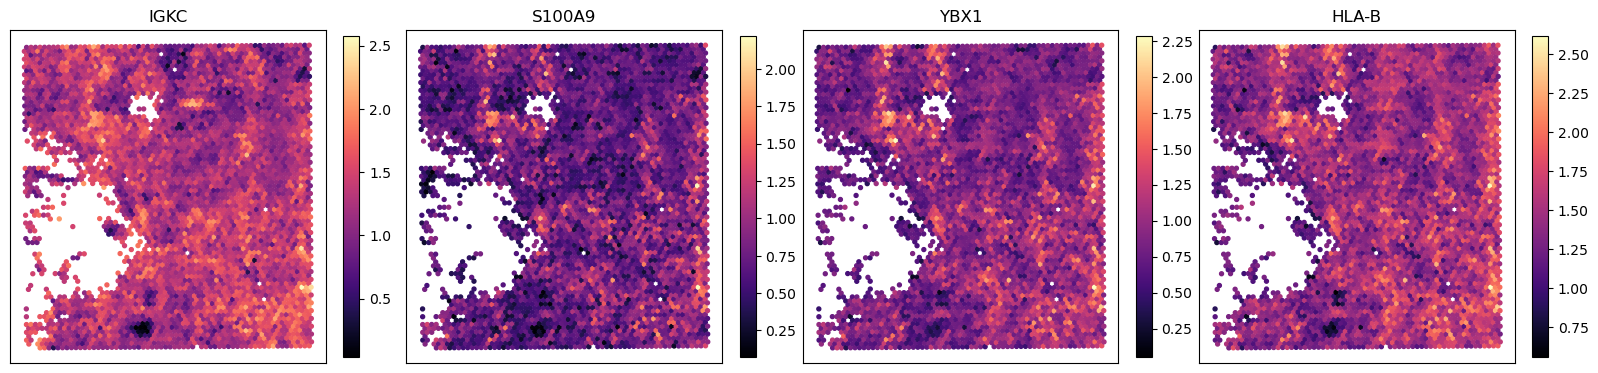

In [8]:
gene_cols = [c for c in hest_pred.columns
             if c not in ('slide_name','x','y','grid_x','grid_y')]
variances = hest_pred[gene_cols].var().sort_values(ascending=False)
top_genes = variances.head(4).index.tolist()
print('top-variance genes:', top_genes)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, g in zip(axes, top_genes):
    sc = ax.scatter(hest_pred['x'], hest_pred['y'],
                    c=hest_pred[g], s=8, cmap='magma')
    plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_title(g); ax.invert_yaxis()
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## Wrap-up

The pipeline accepts two kinds of input:

- **`predict_grid(...)`** for whole-slide images without predefined spot
  coordinates (TCGA, in-house WSIs, …).
- **`predict_spots(...)`** for Visium / spot-aligned inputs (HEST, 10x, …).

Both return a DataFrame indexed by tile / spot id with one column per
predicted gene (≈14 K). See the [ge_model README](../README.md) for the
full API, configuration knobs (smoothing, edge thresholds, slide
backends), and the CLI scripts under `scripts/`.
